# Putting the time axis in minutes, and testing whether it deserves to be

## Scope

The cleavage intensity of the model is

$$\lambda_{\pi,b} = w_\pi \exp(\alpha + \beta\,S^{M}_{\pi,b}),$$

and $\alpha$ is not identified by anything measured so far. Every score, every
ranking and every ordering of events is independent of it: it multiplies the
whole hazard by a constant and therefore only sets the **unit of time**.

Without $\alpha$ the time course exists but its axis is arbitrary. This
notebook fixes it against measured serum half-lives, so that a horizon can be
stated in minutes.

## Two things that must not be conflated

The half-life data are used for two different purposes here, and only one of
them is a test.

**Calibration.** The total hazard factorises as
$\Lambda = e^{\alpha}\Lambda_0$, where $\Lambda_0$ carries the scores and the
weights. Taking logarithms, $\log\Lambda = \alpha + \log\Lambda_0$, so the
fitted $\alpha$ is the mean offset between the observed and the modelled log
rate. It is a one-line closed form and it **cannot fail**: some constant always
fits. Nothing is learned from the fact that it does.

**Validation B.** Whether $\log\Lambda_0$ orders the peptides the way the
observed degradation rates do. This can fail, and it is the only claim in the
notebook that carries information.

Reporting them together would let a successful calibration be read as a
successful model, so they are reported apart.

## The label

A measured half-life becomes a first-order degradation rate,

$$k_{obs} = \frac{\ln 2}{t_{1/2}}.$$

The filters are those of `0_12`: human serum, in vitro, linear, quantitative
half-life with a unit, standard residues only.

## What bounds the answer

The same sequence measured in two publications differs by up to a factor of 21
(`0_12`). The calibration constant therefore carries a wide interval, which is
reported and is meant to be propagated into any horizon quoted in minutes.

## Inputs and outputs

Inputs: `raw/peplife2/human_serum.json`, `raw/dramp/stability_amps.xlsx`,
`results/2_07_model_panel.csv`, `data/merops/`,
`data/reference/human_proteome/composition.json`.

Output: `results/3_01_time_axis_calibration.csv`.

In [1]:
import json
import re
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    MEROPS_AMINO_ACIDS,
    EventGeometry,
    Fragment,
    ProteaseKinetics,
    fragment_events,
    load_amino_acid_background,
    load_protease_panel,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
# Coefficient converting a window score into a log-intensity. The only per-protease
# estimate that survived held-out validation is kallikrein 1, whose slope is 0.404
# orders of magnitude of kcat/KM per nat; converted to natural logarithms that is
# the value used here for every protease.
SCORE_SLOPE = 0.404 * np.log(10.0)
N_BOOTSTRAP = 2000
SEED = 20260920

In [3]:
human_background = load_amino_acid_background(
    common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"
)
panel = pd.read_csv(common.RESULTS_ROOT / "2_07_model_panel.csv")
print(f"panel: {len(panel)} proteases | score slope beta = {SCORE_SLOPE:.3f} per nat")

panel: 57 proteases | score slope beta = 0.930 per nat


## The half-life set

PEPlife2 supplies the primary serum measurements and DRAMP the secondary ones,
deduplicated against it by sequence, exactly as in `0_12`.

In [4]:
UNIT_TO_MINUTES = {
    "minute": 1.0, "minutes": 1.0, "min": 1.0,
    "hour": 60.0, "hours": 60.0, "h": 60.0, "hr": 60.0,
    "day": 1440.0, "days": 1440.0,
    "second": 1 / 60, "seconds": 1 / 60, "sec": 1 / 60,
}
NUMERIC = re.compile(r"^\s*([0-9]*\.?[0-9]+)\s*$")
STANDARD = re.compile(f"^[{MEROPS_AMINO_ACIDS}]+$")


def to_minutes(value: object, unit: object) -> float:
    """Convert one reported half-life to minutes.

    :param value: Reported half-life.
    :param unit: Reported unit.
    :return: Half-life in minutes, ``nan`` when it cannot be converted.
    """

    match = NUMERIC.match(str(value))
    factor = UNIT_TO_MINUTES.get(str(unit).strip().lower())
    if match is None or factor is None:
        return float("nan")
    return float(match.group(1)) * factor


payload = json.loads((common.SERUM_RAW / "peplife2" / "human_serum.json").read_text())
peplife = pd.DataFrame(payload["data"])
peplife["half_life_min"] = [
    to_minutes(value, unit) for value, unit in zip(peplife["half_life"], peplife["units_half"])
]
peplife["sequence"] = peplife["seq"].str.upper()
serum = peplife[
    peplife["half_life_min"].notna()
    & peplife["vivo_vitro"].str.strip().str.lower().eq("in vitro")
    & peplife["lin_cyc"].str.strip().str.lower().str.startswith("linear")
    & peplife["sequence"].str.fullmatch(STANDARD)
][["sequence", "half_life_min", "pmid"]].assign(source="peplife2")

dramp = pd.read_excel(common.SERUM_RAW / "dramp" / "stability_amps.xlsx")
dramp["sequence"] = dramp["Sequence"].astype(str).str.upper().str.strip()
extracted = dramp["half_life"].astype(str).str.extract(
    r"(?P<value>[0-9]*\.?[0-9]+)\s*(?P<unit>minutes?|min|hours?|h|days?|seconds?|sec)\b",
    flags=re.IGNORECASE,
)
dramp["half_life_min"] = [to_minutes(v, u) for v, u in zip(extracted["value"], extracted["unit"])]
dramp_serum = dramp[
    dramp["sequence"].str.fullmatch(STANDARD)
    & dramp["half_life_min"].notna()
    & (
        dramp["Assay"].astype(str).str.lower().str.contains("serum")
        | dramp["Type"].astype(str).str.lower().str.contains("serum")
        | dramp["half_life"].astype(str).str.lower().str.contains("serum")
    )
][["sequence", "half_life_min", "Pubmed_ID"]].rename(columns={"Pubmed_ID": "pmid"}).assign(
    source="dramp"
)

observations = pd.concat([serum, dramp_serum], ignore_index=True)
observations = observations[observations["half_life_min"] > 0]
## One value per sequence: the median across publications, with the spread kept.
labels = (
    observations.groupby("sequence")
    .agg(
        half_life_min=("half_life_min", "median"),
        n_measurements=("half_life_min", "size"),
        spread_log10=("half_life_min", lambda values: float(np.log10(values.max() / values.min()))),
        sources=("source", lambda values: ";".join(sorted(set(values)))),
    )
    .reset_index()
)
labels["k_obs_per_min"] = np.log(2.0) / labels["half_life_min"]
labels["length"] = labels["sequence"].str.len()

print(f"sequences with a usable serum half-life: {len(labels)}")
print(labels["sources"].value_counts().to_string())
print(f"half-life range: {labels['half_life_min'].min():.1f}-{labels['half_life_min'].max():.1f} min")
repeated = labels.query("n_measurements > 1")
print(f"sequences measured more than once: {len(repeated)}, "
      f"median spread {repeated['spread_log10'].median():.2f} log10 units"
      if len(repeated) else "no sequence measured more than once")

sequences with a usable serum half-life: 68
sources
dramp       49
peplife2    19
half-life range: 1.0-7020.0 min
sequences measured more than once: 14, median spread 0.76 log10 units


## The modelled hazard

For each sequence the total hazard of the intact peptide is assembled from the
panel, with the geometry of every protease respected. Two weightings are
computed: uniform, and weighted by the circulating amount. Proteases without an
abundance value are excluded from the weighted variant rather than given a
default.

In [5]:
human_panel = load_protease_panel(34, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu")
matrices = human_panel.matrices.numpy().astype(np.float64)
index_of = {code: index for index, code in enumerate(human_panel.codes)}

available = panel[panel["merops_code"].isin(index_of)].copy()
with_abundance = available.dropna(subset=["abundance_pg_per_l"])
print(f"panel proteases with a matrix in the human dataset: {len(available)}")
print(f"  of those with an abundance value: {len(with_abundance)}")


def build_kinetics(frame: pd.DataFrame, weights: np.ndarray) -> ProteaseKinetics:
    """Assemble the panel for the dynamics with a given weighting.

    :param frame: Panel rows to include.
    :param weights: Per-protease weight, same order as ``frame``.
    :return: The assembled kinetics.
    """

    return ProteaseKinetics(
        matrices=np.stack([matrices[index_of[code]] for code in frame["merops_code"]]),
        geometries=tuple(EventGeometry(value) for value in frame["event_geometry"]),
        weights=weights,
        codes=tuple(frame["merops_code"]),
        intercept=0.0,
        slope=SCORE_SLOPE,
    )


variants = {
    "uniform": build_kinetics(available, np.ones(len(available))),
    "concentration": build_kinetics(
        with_abundance,
        (with_abundance["abundance_pg_per_l"] / with_abundance["abundance_pg_per_l"].median()).to_numpy(),
    ),
}

for name, kinetics in variants.items():
    hazards = []
    for sequence in labels["sequence"]:
        events = fragment_events(sequence, (Fragment(0, len(sequence)),), kinetics, human_background)
        hazards.append(float(sum(event.intensity for event in events)))
    labels[f"lambda0_{name}"] = hazards
    print(f"{name:14s} hazard range {min(hazards):.3g} to {max(hazards):.3g}")

panel proteases with a matrix in the human dataset: 57
  of those with an abundance value: 47


uniform        hazard range 59.5 to 5.83e+03


concentration  hazard range 1.86e+03 to 3.94e+06


## Validation B: does the modelled hazard order the measurements?

This is the part that can fail. The comparison is between $\log\Lambda_0$ and
$\log k_{obs}$, before any constant is fitted, because the constant cannot
affect a correlation.

In [6]:
validation = []
for name in variants:
    modelled = np.log(labels[f"lambda0_{name}"].to_numpy())
    observed = np.log(labels["k_obs_per_min"].to_numpy())
    finite = np.isfinite(modelled) & np.isfinite(observed)
    correlation = spearmanr(modelled[finite], observed[finite])

    generator = np.random.default_rng(SEED)
    null = np.array(
        [
            spearmanr(modelled[finite], generator.permutation(observed[finite])).statistic
            for _ in range(N_BOOTSTRAP)
        ]
    )
    empirical_p = float((1 + (np.abs(null) >= abs(correlation.statistic)).sum()) / (1 + len(null)))
    validation.append(
        {
            "weighting": name,
            "n_sequences": int(finite.sum()),
            "spearman_rho": float(correlation.statistic),
            "permutation_p": empirical_p,
        }
    )

validation = pd.DataFrame(validation)
print(validation.round(4).to_string(index=False))
print()
print("length is the obvious confounder: a longer peptide has more bonds and "
      "therefore more hazard, independently of any specificity")
for name in variants:
    modelled = np.log(labels[f"lambda0_{name}"])
    print(f"  {name:14s} rho(log hazard, length) = "
          f"{spearmanr(modelled, labels['length']).statistic:+.3f}")
print(f"  {'k_obs':14s} rho(log k_obs, length)  = "
      f"{spearmanr(np.log(labels['k_obs_per_min']), labels['length']).statistic:+.3f}")

    weighting  n_sequences  spearman_rho  permutation_p
      uniform           68       -0.0393         0.7476
concentration           68       -0.0195         0.8721

length is the obvious confounder: a longer peptide has more bonds and therefore more hazard, independently of any specificity
  uniform        rho(log hazard, length) = +0.446
  concentration  rho(log hazard, length) = +0.390
  k_obs          rho(log k_obs, length)  = -0.274


### The length control

The summed hazard grows with the number of bonds, so it grows with peptide
length whatever the matrices say. If the measured rates were driven by length
too, a correlation would prove nothing; and if they run the other way, the
model is contradicted by the strongest signal in the data.

The control compares three predictors against the measured rate: the modelled
hazard, the peptide length alone, and the hazard after the length trend is
removed from both sides.

In [7]:
length = labels["length"].to_numpy(dtype=float)
observed = np.log(labels["k_obs_per_min"].to_numpy())

def residual_of(values: np.ndarray, against: np.ndarray) -> np.ndarray:
    """Remove a linear trend in the predictor from the values.

    :param values: Quantity to correct.
    :param against: Predictor whose linear trend is removed.
    :return: Residuals of the least-squares fit.
    """

    slope, intercept = np.polyfit(against, values, 1)
    return values - (slope * against + intercept)


control_rows = [
    {
        "predictor": "peptide length alone",
        "spearman_rho": float(spearmanr(length, observed).statistic),
    }
]
for name in variants:
    modelled = np.log(labels[f"lambda0_{name}"].to_numpy())
    control_rows.append(
        {
            "predictor": f"modelled hazard, {name}",
            "spearman_rho": float(spearmanr(modelled, observed).statistic),
        }
    )
    control_rows.append(
        {
            "predictor": f"modelled hazard, {name}, length removed from both",
            "spearman_rho": float(
                spearmanr(residual_of(modelled, length), residual_of(observed, length)).statistic
            ),
        }
    )

control = pd.DataFrame(control_rows)
print(control.round(3).to_string(index=False))
print()
print("the model and the measurements disagree on the sign of the length effect: "
      "more bonds mean more modelled hazard, while longer peptides are measured "
      "to degrade more slowly")

                                               predictor  spearman_rho
                                    peptide length alone        -0.274
                                modelled hazard, uniform        -0.039
      modelled hazard, uniform, length removed from both         0.119
                          modelled hazard, concentration        -0.020
modelled hazard, concentration, length removed from both         0.087

the model and the measurements disagree on the sign of the length effect: more bonds mean more modelled hazard, while longer peptides are measured to degrade more slowly


## Calibration: fixing the unit of time

With $\log\Lambda = \alpha + \log\Lambda_0$, the least-squares $\alpha$ is the
mean offset. Its uncertainty is estimated by resampling the sequences, which
carries the between-publication disagreement into the interval.

In [8]:
calibration = []
for name in variants:
    modelled = np.log(labels[f"lambda0_{name}"].to_numpy())
    observed = np.log(labels["k_obs_per_min"].to_numpy())
    finite = np.isfinite(modelled) & np.isfinite(observed)
    offsets = observed[finite] - modelled[finite]
    alpha = float(offsets.mean())

    generator = np.random.default_rng(SEED)
    resampled = np.array(
        [
            float(offsets[generator.integers(0, offsets.size, offsets.size)].mean())
            for _ in range(N_BOOTSTRAP)
        ]
    )
    low, high = np.percentile(resampled, [2.5, 97.5])
    calibration.append(
        {
            "weighting": name,
            "alpha": alpha,
            "alpha_ci_low": float(low),
            "alpha_ci_high": float(high),
            "time_scale_uncertainty_log10": float((high - low) / np.log(10.0)),
            "residual_sd_log10": float(offsets.std(ddof=1) / np.log(10.0)),
        }
    )

calibration = pd.DataFrame(calibration)
print(calibration.round(3).to_string(index=False))
print()
for _, row in calibration.iterrows():
    factor = np.exp(row["alpha_ci_high"] - row["alpha_ci_low"])
    print(f"{row['weighting']:14s} the calibrated time unit is uncertain by a factor of "
          f"{factor:.1f}")

    weighting   alpha  alpha_ci_low  alpha_ci_high  time_scale_uncertainty_log10  residual_sd_log10
      uniform -12.269       -12.738        -11.809                         0.403              0.867
concentration -17.642       -18.173        -17.086                         0.472              1.012

uniform        the calibrated time unit is uncertain by a factor of 2.5
concentration  the calibrated time unit is uncertain by a factor of 3.0


### What a horizon in minutes now means

With $\alpha$ fixed, the predicted half-life of a peptide is
$\ln 2 / (e^{\alpha}\Lambda_0)$. The table below shows the calibrated
prediction against the measurement for the sequences that carry one.

In [9]:
best = calibration.sort_values("residual_sd_log10").iloc[0]
weighting = best["weighting"]
labels["predicted_half_life_min"] = np.log(2.0) / (
    np.exp(best["alpha"]) * labels[f"lambda0_{weighting}"]
)
labels["log10_error"] = np.log10(labels["predicted_half_life_min"] / labels["half_life_min"])

print(f"weighting used: {weighting}")
print(f"median absolute error: {labels['log10_error'].abs().median():.2f} log10 units "
      f"(a factor of {10 ** labels['log10_error'].abs().median():.1f})")
print(f"predictions within one order of magnitude: "
      f"{(labels['log10_error'].abs() < 1).mean():.1%}")
print()
print(
    labels.sort_values("half_life_min")[
        ["sequence", "length", "half_life_min", "predicted_half_life_min", "log10_error", "sources"]
    ].head(12).round(2).to_string(index=False)
)

weighting used: uniform
median absolute error: 0.60 log10 units (a factor of 4.0)
predictions within one order of magnitude: 77.9%

                            sequence  length  half_life_min  predicted_half_life_min  log10_error  sources
                 VDKPPYLPRPRPPRRIYNH      19            1.0                   126.05         2.10    dramp
                         RPKPQQFFGLM      11            2.0                   161.06         1.91 peplife2
         RAAPYGVRLCGREFIRAVIFTCGGSRW      27            3.1                    91.10         1.47 peplife2
             RAAPYGVRLSGREFIRAVIFTSR      23            4.0                   139.24         1.54 peplife2
                               APGPR       5            5.0                  1396.56         2.45 peplife2
                 VDKPPYLPRPRPPRRIYNR      19            5.0                   159.45         1.50    dramp
                           KRRVRWIIW       9           13.0                    78.12         0.78 peplife2
MTWMEWDREINN

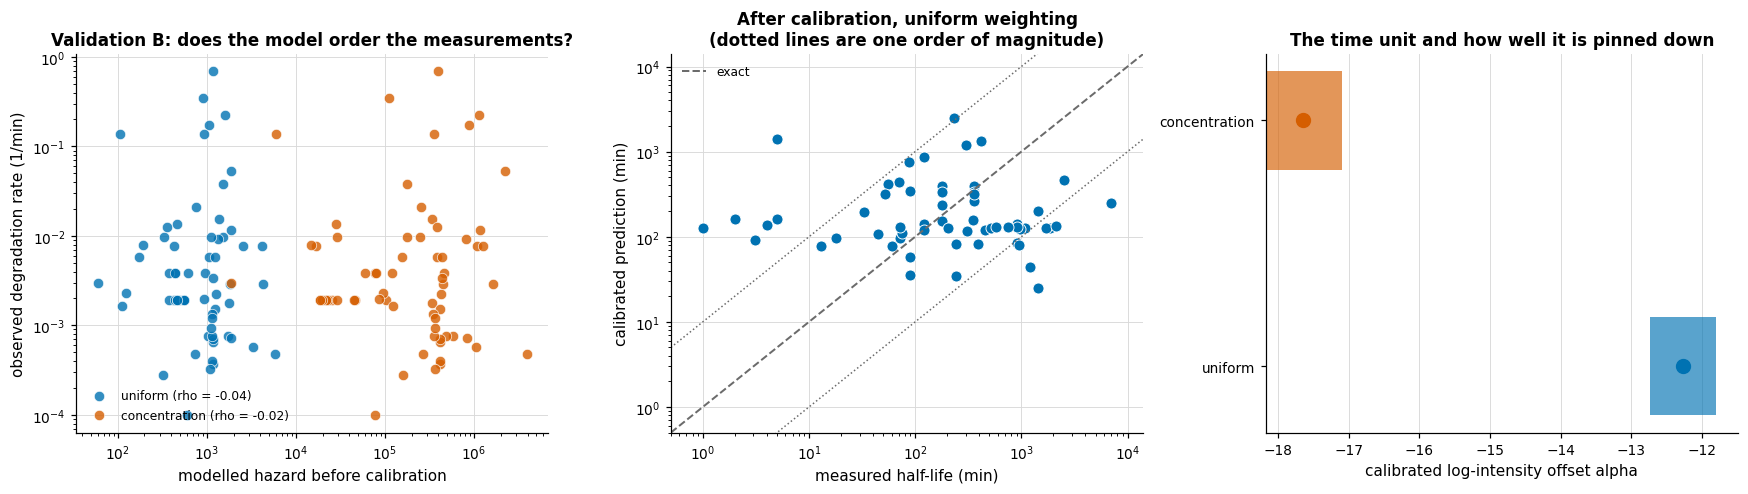

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.6))

ax = axes[0]
for index, name in enumerate(variants):
    ax.scatter(
        labels[f"lambda0_{name}"],
        labels["k_obs_per_min"],
        s=46,
        alpha=0.8,
        color=common.CATEGORICAL_COLORS[index],
        edgecolor="white",
        linewidth=0.5,
        label=f"{name} (rho = {validation.query('weighting == @name')['spearman_rho'].iloc[0]:+.2f})",
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("modelled hazard before calibration")
ax.set_ylabel("observed degradation rate (1/min)")
ax.set_title("Validation B: does the model order the measurements?")
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(
    labels["half_life_min"],
    labels["predicted_half_life_min"],
    s=52,
    color=common.CATEGORICAL_COLORS[0],
    edgecolor="white",
    linewidth=0.6,
)
limits = [
    min(labels["half_life_min"].min(), labels["predicted_half_life_min"].min()) * 0.5,
    max(labels["half_life_min"].max(), labels["predicted_half_life_min"].max()) * 2,
]
ax.plot(limits, limits, color=common.NEUTRAL, linestyle="--", linewidth=1.3, label="exact")
for factor, style in [(10, ":"), (0.1, ":")]:
    ax.plot(limits, [value * factor for value in limits], color=common.NEUTRAL, linestyle=style, linewidth=1.0)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(*limits)
ax.set_ylim(*limits)
ax.set_xlabel("measured half-life (min)")
ax.set_ylabel("calibrated prediction (min)")
ax.set_title(f"After calibration, {weighting} weighting\n(dotted lines are one order of magnitude)")
ax.legend(fontsize=8)

ax = axes[2]
for index, name in enumerate(variants):
    row = calibration.query("weighting == @name").iloc[0]
    ax.barh(
        index,
        row["alpha_ci_high"] - row["alpha_ci_low"],
        left=row["alpha_ci_low"],
        height=0.4,
        color=common.CATEGORICAL_COLORS[index],
        alpha=0.65,
    )
    ax.plot(row["alpha"], index, marker="o", markersize=9, color=common.CATEGORICAL_COLORS[index])
ax.set_yticks(range(len(variants)))
ax.set_yticklabels(list(variants))
ax.set_xlabel("calibrated log-intensity offset alpha")
ax.set_title("The time unit and how well it is pinned down")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## Result

The calibration constant and the validation statistic are written side by side,
so that neither can be quoted without the other.

**The calibration succeeded and the validation did not.** A constant always
fits, and one was fitted; the modelled hazard does not order the measured
degradation rates. Any horizon quoted in minutes from this constant therefore
carries the unit but not a demonstrated rate, and must be labelled as such
wherever it is used.

In [11]:
result = calibration.merge(validation, on="weighting")
result["score_slope_beta"] = SCORE_SLOPE
result["n_proteases"] = [len(available), len(with_abundance)]
result["validated"] = result["permutation_p"] < 0.05
common.save_result(control, "3_01_length_control.csv")
destination = common.save_result(result, "3_01_time_axis_calibration.csv")
common.save_result(
    labels[
        ["sequence", "length", "half_life_min", "n_measurements", "spread_log10", "sources",
         "k_obs_per_min", "lambda0_uniform", "lambda0_concentration",
         "predicted_half_life_min", "log10_error"]
    ],
    "3_01_half_life_predictions.csv",
)
print(f"written: {destination.relative_to(common.ROOT)}")
result.round(4)

written: assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/3_01_time_axis_calibration.csv


,weighting,alpha,alpha_ci_low,alpha_ci_high,time_scale_uncertainty_log10,residual_sd_log10,n_sequences,spearman_rho,permutation_p,score_slope_beta,n_proteases,validated
0,uniform,-12.2690,-12.7377,-11.8087,0.4035,0.8667,68,-0.0393,0.7476,0.9302,57,False
1,concentration,-17.6417,-18.1732,-17.0864,0.4720,1.0115,68,-0.0195,0.8721,0.9302,47,False
